In [2]:
import os, io
from pathlib import Path
from typing import List, Optional
from dotenv import load_dotenv

load_dotenv()

import numpy as np
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

In [3]:
# !pip install transformers

In [4]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

/home/oncreative/anaconda3/envs/modu/lib/python3.11/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [5]:
IMAGE_DIR = Path('data/images')

In [6]:
# 이미지, 테이블, 그래프 -> vision LLM -> text captioning -> embedding 

In [7]:
# 이미지 -> 이미지 인코더 -> embedding

In [8]:
MODEL_NAME = "openai/clip-vit-base-patch32"

In [9]:
model = CLIPModel.from_pretrained(MODEL_NAME, use_safetensors = True).to(DEVICE).eval()

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [10]:
processor = CLIPProcessor.from_pretrained(MODEL_NAME)

In [11]:
# model.config

In [12]:
img = Image.open(IMAGE_DIR / 'shapes_red_blue.png').convert('RGB') # ARGB

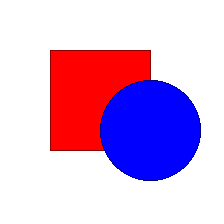

In [13]:
img

In [14]:
candidates = [
    'a red square and a blue ellipse on white background',
    'a quarterly revenue bar chart',
    'a dashboard with KPI cards',
    'a photo of dog'
]

In [15]:
inputs = processor(text=candidates, images=img, return_tensors = 'pt', padding=True).to(DEVICE)

In [16]:
with torch.no_grad():
    out = model(**inputs)


In [17]:
probs = out.logits_per_image.softmax(dim=1)[0].cpu().numpy()

In [18]:
out.logits_per_image.softmax(dim=1)[0].cpu().numpy()

array([9.9993098e-01, 3.2100284e-05, 4.3054294e-07, 3.6526992e-05],
      dtype=float32)

In [19]:
for c, p in zip(candidates, probs):
    print(f" {p}, {c}")

 0.9999309778213501, a red square and a blue ellipse on white background
 3.210028444300406e-05, a quarterly revenue bar chart
 4.3054293996647175e-07, a dashboard with KPI cards
 3.652699160738848e-05, a photo of dog


In [20]:
inputs['pixel_values'].shape

torch.Size([1, 3, 224, 224])

In [21]:
with torch.no_grad():
    vision_out = model.vision_model(pixel_values = inputs['pixel_values'])

In [22]:
vision_out.pooler_output.shape

torch.Size([1, 768])

In [23]:
model.visual_projection(vision_out.pooler_output).shape

torch.Size([1, 512])

In [24]:
model.visual_projection(vision_out.pooler_output)[0].shape

torch.Size([512])

In [25]:
def encode_image_clip(image) -> np.ndarray:
    inputs = processor(images=image.convert('RGB'), return_tensors = 'pt').to(DEVICE)
    with torch.no_grad():
        vision_out = model.vision_model(pixel_values = inputs['pixel_values'])
        pooled = vision_out.pooler_output   # [1, 768]
        projected = model.visual_projection(pooled) # [1, 512]
    
    feat = projected[0].cpu().numpy()  # [512]
    return feat / np.linalg.norm(feat)  # feat / || feat ||



In [ ]:
# image_emb = image_feat / np.linalg.norm(image_feat)

# text_emb = text_feat / np.linalg.norm(text_feat)

In [ ]:
# np.dot(image_feat, text_feat)
# image_feat @ text_feat

In [ ]:
# a, b -> np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [26]:
e = encode_image_clip(Image.open(IMAGE_DIR / 'shapes_red_blue.png'))

In [27]:
e.shape

(512,)

In [28]:
np.linalg.norm(e)

np.float32(0.99999994)

In [29]:
inputs = processor(text=['a red square and a blue ellipse on white background'], return_tensors = 'pt', padding=True).to(DEVICE)
inputs

{'input_ids': tensor([[49406,   320,   736,  3999,   537,   320,  1746,  3367,  5423,   525,
          1579,  5994, 49407]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

In [30]:
inputs['input_ids'].shape

torch.Size([1, 13])

In [31]:
model.text_model(input_ids = inputs['input_ids'], attention_mask = inputs.get('attention_mask')).pooler_output.shape

torch.Size([1, 512])

In [32]:
def encode_text_clip(text : str) -> np.ndarray:
    inputs = processor(text=[text], return_tensors = 'pt', padding=True).to(DEVICE)
    with torch.no_grad():
        text_out = model.text_model(input_ids = inputs['input_ids'], attention_mask = inputs.get('attention_mask'))
        pooled = text_out.pooler_output # (1, 512)
        projected = model.text_projection(pooled)  # (1, 512)
    
    feat = projected[0].cpu().numpy()  # [512]
    return feat / np.linalg.norm(feat)  # feat / || feat ||

In [33]:
t = encode_text_clip('a red square and a blue ellipse on white background')
t.shape

(512,)

In [35]:
image_paths = sorted(IMAGE_DIR.glob('*.png'))
image_paths

[PosixPath('data/images/_eq_gauss.png'),
 PosixPath('data/images/chart_monthly_sales.png'),
 PosixPath('data/images/chart_quarterly.png'),
 PosixPath('data/images/dashboard_v1.png'),
 PosixPath('data/images/dashboard_v2.png'),
 PosixPath('data/images/document_invoice.png'),
 PosixPath('data/images/document_report.png'),
 PosixPath('data/images/gradient_shapes.png'),
 PosixPath('data/images/ir_report_page.png'),
 PosixPath('data/images/org_chart.png'),
 PosixPath('data/images/shapes_red_blue.png'),
 PosixPath('data/images/test_counting.png'),
 PosixPath('data/images/test_small_text.png'),
 PosixPath('data/images/test_spatial.png')]

In [36]:
embeddings = np.stack([encode_image_clip(Image.open(p)) for p in image_paths])
embeddings.shape

(14, 512)

In [37]:
queries = [
    'a bar chart of revenue',
    'an invoice document', 
    'a dashboard with KPIs',
    'korean text'
]

In [38]:
for q in queries:
    q_emb = encode_text_clip(q)
    sims = embeddings @ q_emb
    top3 = np.argsort(-sims)[:3]
    print(q)
    for i in top3:
        print(f" {sims[i]} ---- {image_paths[i].name}")

a bar chart of revenue
 0.2951543629169464 ---- chart_quarterly.png
 0.2849935293197632 ---- chart_monthly_sales.png
 0.2651922404766083 ---- ir_report_page.png
an invoice document
 0.299247145652771 ---- document_invoice.png
 0.2611232101917267 ---- test_small_text.png
 0.23696690797805786 ---- document_report.png
a dashboard with KPIs
 0.3255186080932617 ---- dashboard_v2.png
 0.32344377040863037 ---- dashboard_v1.png
 0.2791062593460083 ---- chart_monthly_sales.png
korean text
 0.23687079548835754 ---- _eq_gauss.png
 0.23490531742572784 ---- shapes_red_blue.png
 0.21888156235218048 ---- test_spatial.png


In [39]:
def build_image_index(paths) -> tuple: #(embs , paths):
    embs = np.stack([encode_image_clip(Image.open(p)) for p in paths])
    return embs, list(paths)

In [40]:
def search_by_text(text, embeddings, paths, k=3) -> list:
    q = encode_text_clip(text)
    sims = embeddings @ q
    top = np.argsort(-sims)[:k]
    return [(paths[i], float(sims[i])) for i in top]

In [42]:
embs, paths = build_image_index(image_paths)
for q in ['bar chart', 'math equation']:
    for p, s in search_by_text(q, embs, paths, k=2):
        print(q)
        print(f"{s}  {p.name}")

bar chart
0.2896374762058258  chart_quarterly.png
bar chart
0.2765522003173828  chart_monthly_sales.png
math equation
0.29785099625587463  _eq_gauss.png
math equation
0.2495494782924652  test_spatial.png


In [43]:
def search_by_image(query_image, embeddings, paths, k=3):
    q = encode_image_clip(query_image)
    sims = embeddings @ q
    top = np.argsort(-sims)[:k]
    return [(paths[i], float(sims[i])) for i in top]

In [ ]:
# FAISS
# chromadb

# qdrant

In [ ]:
# !pip install qdrant-client

In [44]:
from qdrant_client import QdrantClient

In [45]:
from qdrant_client.models import VectorParams, Distance, PointStruct, NamedVector, Filter, FieldCondition, MatchValue

In [47]:
client = QdrantClient(":memory:")
COLLECTION = "multimodal_demo"

In [48]:
client.create_collection(collection_name = COLLECTION, 
                        vectors_config = {
                            "image" : VectorParams(
                                            size = 512,
                                            distance = Distance.COSINE
                                    ),
                            "caption" : VectorParams(
                                            size = 512,
                                            distance = Distance.COSINE
                                    ),
                        })

True

In [49]:
def filename_to_caption(path):
    return path.stem.replace("_", "")  # chart_quarterly.png -> chart quarterly